# Advanced Chemical Reaction Engineering (CBE 60546)
## Homework 5
## Due October 13, 2025

Carefully and neatly document your answers. Use Jupyter/Collab for all plots. See sample code at https://github.com/wmfschneider/CBE60546/blob/main/Resources/Examples.ipynb.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint, solve_ivp
from scipy.interpolate import BPoly

# Q1. It all follows
The reaction sequence $\ce{A <-> B <-> C}$, while simple, can illustrate a number of interesting limiting behaviors. Consider a sequence with the following characteristics at 500 K:

|   | $\Delta G^{\circ,\ddagger}(500)$  | $\Delta G^{\circ}(500)$  |   |
|-|:-:|:-:|:-|
| $\ce{A <-> B}$ | 100  | 5 | kJ/mol |
| $\ce{B<-> C}$  | 120 | -5 | kJ/mol |

### Q1.1. Plot the free energy surface of the reaction sequence.

### From lecture example notebook...

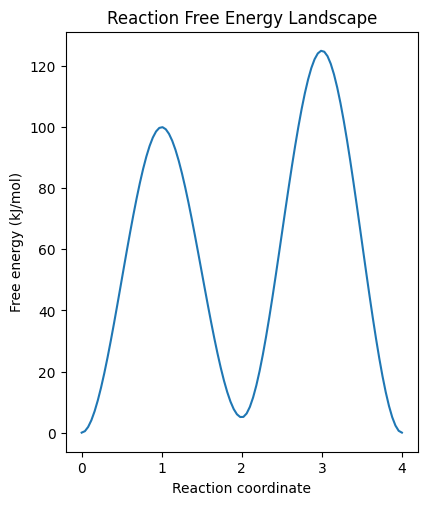

In [2]:
kB = 8.61733e-5      # eV /K
h = 4.13566766e-15  # eV s
R0 = 8.31441 # J/mol/K
    
# function to plot free energy surface. Takes G_i = [G_TS,G_rxn]
def free_energy_surface(G1,G2):
    p1 = BPoly.from_derivatives([0, 1, 2, 3, 4], [[0, 0], [G1[0], 0], [G1[1], 0], [G1[1]+G2[0],0], [G1[1]+G2[1],0]])
    x=np.linspace(0,4,100)
    y=p1(x)

    plt.figure(figsize=(10,12))
    plt.subplot(2,2,1)
    plt.plot(x,y)
    plt.ylabel('Free energy (kJ/mol)')
    plt.xlabel('Reaction coordinate')
    plt.title('Reaction Free Energy Landscape')

G1 = [100,5]
G2 = [120,-5]
free_energy_surface(G1,G2)

### Q1.2. Determine forward and reverse rate constants for both reactions.

### From lecture example notebook...

In [3]:
def rate_constants(T,G1,G2):
    G1dd = G1[0]
    Gn1dd = G1dd-G1[1]
    G2dd = G2[0]
    Gn2dd = G2dd-G2[1]

    k = (kB*T/h)*np.exp(-np.array([G1dd,Gn1dd,G2dd,Gn2dd])*1000./(R0*T))
    return k

T = 500
k = rate_constants(T,G1,G2)
print('T = {:4.1f}'.format(T))
print('k1 = {:6.3e}     k-1 = {:6.3e}         k2 = {:6.3e}      k-2 = {:6.3e} /s'.format(k[0],k[1],k[2],k[3]))

T = 500.0
k1 = 3.724e+02     k-1 = 1.240e+03         k2 = 3.031e+00      k-2 = 9.106e-01 /s


### Q1.3. Suppose 1 M A is fed into a tubular reactor of cross-sectional area 1 cm$^2$ at a volumetric flow rate of 1 cm$^3$/second. Plot the concentrations of A, B, and C as a function of the length down the reactor.

#### Define ODEs
#### For $\ce{C_A: dC_A/dt = - r_1 + r_{-1} = - k_1[C_A] + k_{-1}[C_B] }$
#### For $\ce{C_B: dC_B/dt = + r_1 - r_{-1} - r_2 + r_{-2} = + k_1[C_A] - k_{-1}[C_B] - k_2[C_B] + k_{-2}[C_C]}$
#### For $\ce{C_C: dC_C/dt = + r_2 - r_{-2} = + k_2[C_B] - k_{-2}[C_C]} $
### Residence Time

The residence time $\tau$ is defined as:
$\tau = \frac{V}{v} = \frac{A \cdot l}{v}$
Given: $A = 1~\text{cm}^2, \quad v = 1~\text{cm}^3/\text{s}$

Therefore:
$\tau = \frac{(1~\text{cm}^2) \cdot l}{1~\text{cm}^3/\text{s}} = \left( \frac{l}{\text{cm}} \right)\text{s}$

Hence, the **residence time** (or **space time**) is numerically equal to the **reactor length in cm**, when $A=1~\text{cm}^2$ and $v=1~\text{cm}^3/\text{s}$.

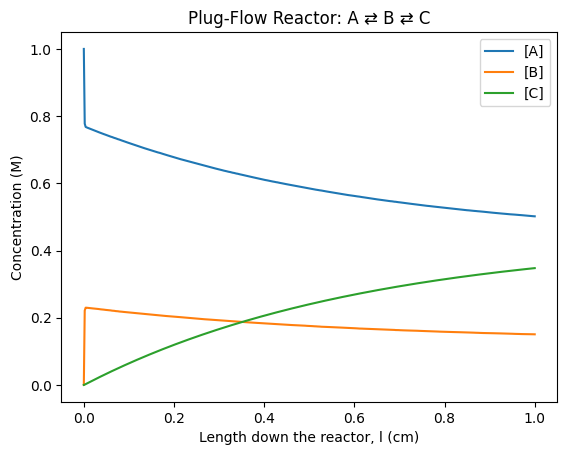

In [4]:
k1 = k[0]
km1 = k[1]
k2 = k[2]
km2 = k[3]

def ODE(tau, y):
    CA, CB, CC = y
    dCA = -k1*CA + km1*CB  
    dCB =  k1*CA - km1*CB - k2*CB + km2*CC
    dCC =  k2*CB - km2*CC # r2-rm2
    return [dCA, dCB, dCC]

CA0, CB0, CC0 = 1.0, 0.0, 0.0  # M
y0 = [CA0, CB0, CC0]

L_end = 1  # cm
taus = np.linspace(0.0, L_end, 500)

sol = solve_ivp(ODE, (taus[0], taus[-1]), y0, t_eval=taus)

CA, CB, CC = sol.y
plt.plot(sol.t, CA, label='[A]')
plt.plot(sol.t, CB, label='[B]')
plt.plot(sol.t, CC, label='[C]')
plt.xlabel('Length down the reactor, l (cm)')
plt.ylabel('Concentration (M)')
plt.title('Plug-Flow Reactor: A ⇄ B ⇄ C')
plt.legend()

### Q1.4. What is the maximum possible yield of C? Why is it $<1$?

In [5]:
Y = CC[-1]/CA[0]
print(f'Maximum yield of C is {round(Y,3)}')

Maximum yield of C is 0.348


The yield of C is less than 1 because the reactions are reversible and limited by equilibrium. Even with a longer reactor, the system would only approach this equilibrium composition, not full conversion. 

### Q1.5. Plot the reversibility ($1 - r_r/r_f)$ of each reaction step as a function of the length down the reactor. What do you notice?

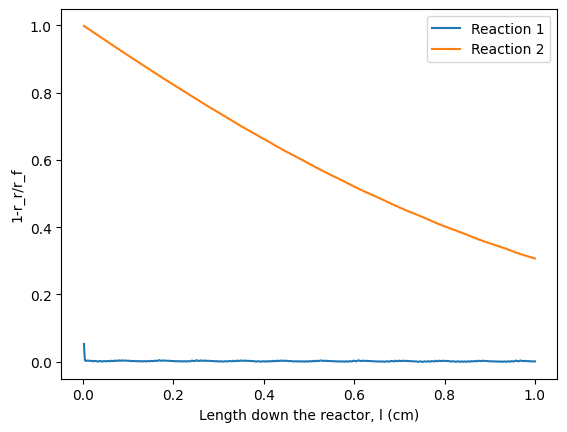

In [6]:
r1f = k1*CA[1:]
r1r = km1*CB[1:]
r2f = k2*CB[1:]
r2r = km2*CC[1:]
plt.plot(sol.t[1:], 1-r1r/r1f, label='Reaction 1')
plt.plot(sol.t[1:], 1-r2r/r2f, label='Reaction 2')
plt.xlabel('Length down the reactor, l (cm)')
plt.ylabel('1-r_r/r_f')
plt.legend()

### Q1.6. Based on your observations, what might be a useful approximation to simplify this reaction network? Propose an analytical rate model based on your approximation and compare your model to the full solutions. (*Hint* think equilibrium.)

Because $1-\beta$ for reaction 1 goes to zero, that reaction is in equilibrium. We can make a *pre-equilibrium* approximation to relate the concentrations of A and B:

$K_1=\frac{k_1}{k_{-1}} \quad\Rightarrow\quad [\ce{B}]=K_1[\ce{A}]$

From the stoichiometry, $[\ce{A}]+[\ce{B}]+[\ce{C}]= C_0$ is a constant. Thus,

$[\ce{A}]=\frac{C_0-[\ce{C}]}{1+K_1}$ and $[\ce{B}]=\frac{K_1}{1+K_1}\,(C_0-[\ce{C}])$

Net rate for $\ce{B <=> C}$:

$\frac{d[\ce{C}]}{d\tau}=k_2[\ce{B}]-k_{-2}[\ce{C}] = k_2\frac{K_1}{1+K_1}(C_0-[\ce{C}])-k_{-2}[\ce{C}]$

With initial condition, $[\ce{C}]=0$, the equation integrates to
$\boxed{[\ce{C}]=\frac{k_f}{k_f+k_{-2}}
\left(1-e^{-(k_f+k_{-2})\tau}\right)}$, 
where $k_f=\frac{K_1}{1+K_1}k_2$.

At $l=\tau=1 cm: [\ce{C}] \approx 0.434\left(1-e^{-1.610}\right)\approx 0.347\ \mathrm{M}$, equivalent to the yield above.

Even simpler would be to assume that the first reaction is *irreversible*. (That's what Bill would do.) Then

$\frac{d[\ce{C}]}{d\tau}=k_2[\ce{B}] = k_2 \frac{K_1}{1+K_1}\,(C_0-[\ce{C}])$

$C_C(\tau) = C_0 \left ( 1-e^{-k_f \tau}\right )$

This would hold at short times. It would be interesting to plot both of these solutions vs $\tau$ to compare performance.

# A Q2. Radical Path
At high temperature, ethylene can be hydrogenated to ethane. The proposed mechanism has four steps, all of which are presumed to be elementary under realistic conditions.

$$ \ce{C2H4(g) + H2(g) ->[k_{1}] C2H5*(g) + H*(g)} $$
$$ \ce{H*(g) + C2H4(g) ->[k_{2}] C2H5*(g)} $$
$$ \ce{C2H5*(g) + H2(g) ->[k_{3}] C2H6(g) + H*(g)} $$
$$ \ce{C2H5*(g) + H*(g) ->[k_{4}] C2H6(g)} $$

### Q2.1. Identify the reactants, products, and intermediates, and state whether the mechanism is open or closed.

Reactants: $ \ce{C2H4(g), H2(g)}$

Products: $\ce{C2H6(g)}$

Intermediates: $\ce{H*(g), C2H5*(g)}$

Mechanism is open. Ever intermediate is consumed in the network.

### Q2.2. Why is it reasonable to assume that the first reaction is irreversible (that is, that the forward reaction rate is much greater than the reverse)? What about the second reaction?

The reverse of reaction 1 is a reaction between two reactive intermediates, both of which will have low concentration. Because the rate is the product of both concentrations, rate will be very small. Reverse of reaction 2 will be enodtheric and slow relative to other reactions of ethyl radical. 

### Q2.3. Based on the mechanism above, write an expression for the rate of disappearance of ethylene.

$$
\frac{d[\mathrm{C_2H_4}]}{dt} = - r_1 - r_2
= - k_1[\mathrm{C_2H_4}][\mathrm{H_2}]
- k_2[\mathrm{H}\cdot][\mathrm{C_2H_4}]
$$

### Q2.4. Apply the quasi-steady-state approximation seperately to H atoms and ethyl radicals. Use the results to derive expressions for the concentrations of each in terms of only reactants and products.

**Species (5 total):**  
$
[A]=[\mathrm{C_2H_4}],\quad [H_2]=[\mathrm{H_2}],\quad [H]=[\mathrm{H}\cdot],\quad [E]=[\mathrm{C_2H_5}\cdot],\quad [P]=[\mathrm{C_2H_6}]
$

---

#### QSSA balances (apply to radicals only)
$$ (Eq.1)    \frac{d[H]}{dt} = 0 = k_1[A][H_2] + k_3[E][H_2] + k_{-2}[E] - k_2[H][A] - k_4[H][E] $$
$$ (Eq.2)    \frac{d[E]}{dt} = 0 = k_1[A][H_2] + k_2[H][A] - k_{-2}[E] - k_3[E][H_2] - k_4[H][E] $$


_Eq.1 - Eq.2:_ $ k_4[H][E] = k_1[A][H_2]. \tag{1} $

_Solve the second for \(E\):_
$
[E] = \frac{k_2[H][A]}{k_{-2}+k_3[H_2]}. \tag{2}
$

_Substitute [E] into Eq.1 - Eq.2 to eliminate [E]:_
$
k_4[H]\left(\frac{k_2[H][A]}{k_{-2}+k_3[H_2]}\right) = k_1[A][H_2]
\;\Rightarrow\;
\boxed{[H] = \sqrt{\frac{k_1}{k_4 k_2}\,[H_2]\,(k_{-2}+k_3[H_2])}}.
$

_Back-substitute to obtain \(E\):_
$
\boxed{
[E] = \frac{k_2[A]}{k_{-2}+k_3[H_2]}\,
\sqrt{\frac{k_1}{k_4 k_2}\,[H_2]\,(k_{-2}+k_3[H_2])}
}.
$

### Q2.5. Combine your answers to obtain an expression for the rate of disapearance of ethylene that involves only reactants and products. What is the apparent reaction order with respect to $\ce{H2}$? To $\ce{C2H4}$?

Starting from:

$
-\frac{d[\mathrm{C_2H_4}]}{dt}
= k_1[\mathrm{C_2H_4}][\mathrm{H_2}]
+ k_2[\mathrm{C_2H_4}][\mathrm{H}\cdot]
$

and substituting the QSSA result for the hydrogen radical:

$
[\mathrm{H}\cdot]
= \sqrt{\frac{k_1}{k_4 k_2}\,[\mathrm{H_2}]\,(k_{-2}+k_3[\mathrm{H_2}])},
$

we obtain:

$
\boxed{
-\frac{d[\mathrm{C_2H_4}]}{dt}
= [\mathrm{C_2H_4}]
\left[
k_1[\mathrm{H_2}]
+ \sqrt{\frac{k_1 k_2}{k_4}}\,
\sqrt{[\mathrm{H_2}]\,(k_{-2}+k_3[\mathrm{H_2}])}
\right]
}
$

---

### Apparent Reaction Orders

- **With respect to ethylene $(\mathrm{C_2H_4})$**  
  → **First order**, since the overall rate is directly proportional to $([\mathrm{C_2H_4}])$.

- **With respect to hydrogen $(\mathrm{H_2})$**
  - **At low $[\mathrm{H_2}]$**, $(k_{-2} \gg k_3[\mathrm{H_2}]$):  
    $
    -\frac{d[A]}{dt} \propto [A][H_2]^{1/2}
    \quad \Rightarrow \quad \text{Half-order in } \mathrm{H_2}.
    $
  - **At high $[\mathrm{H_2}]$**, $(k_3[\mathrm{H_2}] \gg k_{-2})$:  
    $
    -\frac{d[A]}{dt} \propto [A][H_2]
    \quad \Rightarrow \quad \text{First-order in } \mathrm{H_2}.
    $

---

### Q2.6. What is the apparent rate constant? Do you expect it to exhibit Arrhenius behavior in general?

From the overall rate expression:

$-\dfrac{d[\ce{C2H4}]}{dt}
= [\ce{C2H4}]
\left[
k_1[\ce{H2}]
+ \sqrt{\dfrac{k_1 k_2}{k_4}}\,
\sqrt{[\ce{H2}]\,(k_{-2}+k_3[\ce{H2}])}
\right]$

the **apparent first-order rate constant in ethylene** is defined as:

$\boxed{
k_{\mathrm{app}}([\ce{H2}],T)
= k_1(T)[\ce{H2}]
+ \sqrt{\dfrac{k_1(T)k_2(T)}{k_4(T)}}\,
\sqrt{[\ce{H2}]\,(k_{-2}(T)+k_3(T)[\ce{H2}])}
}$

---

### Arrhenius Behavior

Each elementary rate constant follows the Arrhenius form:

$k_i(T) = A_i e^{-E_i / RT}$

However, because $k_{\mathrm{app}}$ involves **sums** and **square roots** of these Arrhenius terms, it is **not a simple Arrhenius function** of temperature.

### Q2.7. A competing reaction is ethane dissociation, $\ce{C2H6 -> 2CH3}$. The rate of this reaction is observed to be a function of pressure of a diluent and to reach a limiting value with increasing pressure. Why? 

The competing reaction is:

$
\ce{C2H6 -> 2 CH3}
$

In reality, this reaction proceeds through a **collisional activation mechanism** (Lindemann–Hinshelwood model):

$
\ce{C2H6 + M <=>[k_1C_M][k_{-1}C_M] C2H6^*}
$

$
\ce{C2H6^* ->[k_2] 2 CH3}
$

where $\ce{M}$ is a **diluent (bath gas)** that transfers energy in collisions.

---

### Derivation of the Pressure-Dependent Rate

Applying the steady-state approximation to $\ce{C2H6^*}$ gives:

$
r = k_{\text{eff}}[\ce{C2H6}], \qquad
k_{\text{eff}} = \frac{k_1 k_2 [\ce{M}]}{k_{-1}[\ce{M}] + k_2}.
$

---

### Interpretation

- **Low Pressure Limit** ($k_{-1}[\ce{M}] \ll k_2$): $k_{\text{eff}} \approx k_1[\ce{M}] \quad \Rightarrow \quad r \propto [\ce{M}].$

  The rate increases with pressure because more collisions provide more activation events.

- **High Pressure Limit** ($k_{-1}[\ce{M}] \gg k_2$): $k_{\text{eff}} \approx \frac{k_1 k_2}{k_{-1}}.$

  The overall rate becomes **independent of pressure**

# Q3. It's a dog eat dog world
Rabbits (R) eat grass (G). Coyotes (C) eat rabbits. But there's only so much grass and so many rabbits. A simple model to describe 

|     |        |
|-----|--------|
| $\ce{R + G-> 2 R}$ | Rabbits reproduce when they are well fed! |
| $\ce{C + R-> 2 C}$ | Coyotes too! |
| $\ce{C -> D}$ | Coyotes die eventually too |

Each of these steps is analogous to an elementary step in a reaction network, and all are irreversible (dead coyotes, thankfully, do not come back to life!).

### Q3.1.Write down the differential equations that describe how the populations of rabbits and coyotes evolve with time.

The corresponding rate expressions are:

$
r_1 = k_1[\ce{R}][\ce{G}], \quad
r_2 = k_2[\ce{C}][\ce{R}], \quad
r_3 = k_3[\ce{C}]
$

#### Rate of Change of Rabbits

Rabbits are **produced** in step (1) and **consumed** in step (2):

$
\frac{d[\ce{R}]}{dt} = -r_1 + 2r_1 -r_2 = +r_1 - r_2
$

Substitute the rates:

$
\boxed{
\frac{d[\ce{R}]}{dt}
= k_1[\ce{R}][\ce{G}] - k_2[\ce{C}][\ce{R}]
}
$

#### Rate of Change of Coyotes

Coyotes are **produced** in step (2) and **consumed** in step (3):

$
\frac{d[\ce{C}]}{dt} = -r_2 + 2r_2 - r_3 = +r_2 - r_3
$

Substitute the rates:

$
\boxed{
\frac{d[\ce{C}]}{dt}
= k_2[\ce{C}][\ce{R}] - k_3[\ce{C}]
}
$

### Q3.2. Assume the amount of grass is a constant, that each "reaction" has a rate constant of unity, and that a field starts with 20 times more rabbits than coyotes. Solve your differential equations and plot the evolution of the populations of rabbits and coyotes with time. What do you think?

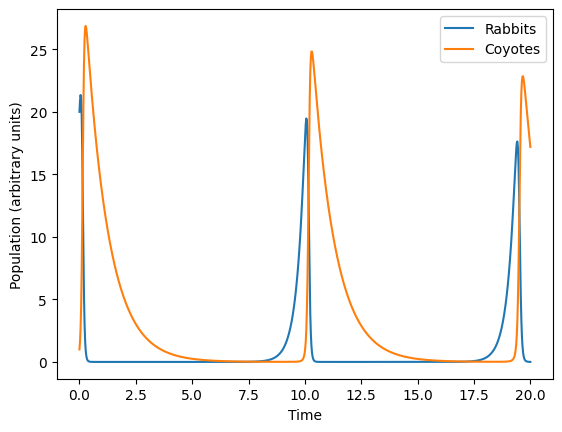

In [8]:
G = 1.0
k1 = 3.0 # You can try 1.0, 2.0, 3.0 and see the differences
k2 = k3 = 1.0

def ODE(t, y):
    R, C = y
    dRdt = k1*R*G - k2*C*R  
    dCdt = k2*C*R - k3*C      
    return [dRdt, dCdt]

# Initial conditions: 20× more rabbits than coyotes
C0 = 1.0
R0 = 20.0
y0 = [R0, C0]

# Integrate
t_span = (0.0, 20.0)
t_eval = np.linspace(*t_span, 800)
sol = solve_ivp(ODE, t_span, y0, t_eval=t_eval)

R, C = sol.y

plt.plot(sol.t, R, label='Rabbits')
plt.plot(sol.t, C, label='Coyotes')
plt.xlabel('Time')
plt.ylabel('Population (arbitrary units)')
plt.legend()
plt.show()

Solutions trace cycles around that point: rabbits boom → coyotes boom (eating rabbits) → rabbits crash → coyotes crash → repeat.

# Q4. And so it grows
Polyethylene ($\ce{-(CH2-CH2)_n-}$ is the polymer of ethylene and is familiar as the main component of those horrible plastic grocery bags. Ethylene is polymerized by a zirconium-based single-site catalyst that for simplicity we can represent as \ce{M-H}. The Cossee-Arlman mechanism for polymerization is

|    |    |
|----|----|
| $\ce{M-H + C2H4 ->[k_1] M-C2H5}$ ($\ce{M-R_1}$) | initiation |
| $\ce{M-R_n + C2H4 ->[k_2] M-R_{n+1}}$   | propagation| 
| $\ce{M-R_n ->[k_3] M-H + R_n}$ | termination |

### Q4.1. Write expressions for the rate of initiation, propagation, and termination. (*Hint* Consider propagation and termination rates to be the sum of the contributions from each intermediate $\ce{M-R_n}$.

Let $[\ce{M\!-\!R_n}]$ be the concentration of chains of length $n$ on the metal center and define the
total concentration of **active sites (growing chains)**:
$
[\ce{M^*}] \equiv \sum_{n=1}^{\infty} [\ce{M-R_n}].
$

**Initiation rate**
$
\boxed{\,r_i = k_1[\ce{M-H}][\ce{C2H4}]\,}
$

**Propagation rate** (sum over all chain lengths)
$
\boxed{\,r_p = \sum_{n=1}^{\infty} k_2[\ce{M-R_n}][\ce{C2H4}]
      \;=\; k_2[\ce{C2H4}]\,[\ce{M^*}]\,}
$

**Termination rate** (sum over all chain lengths)
$
\boxed{\,r_t = \sum_{n=1}^{\infty} k_3[\ce{M-R_n}]
      \;=\; k_3[\ce{M^*}]\,}
$

### Q4.2. What relation would hold if $\ce{M-H}$ was at quasi-steady state?

If $\ce{M–H}$ is at QSS, its rate of formation equals its rate of consumption:

**QSS condition**
$
\boxed{r_i = r_t
\;\Rightarrow\; k_1[\ce{M–H}][\ce{C2H4}] = k_3[\ce{M^*}]\,}
$

Equivalently,
$
\boxed{\, [\ce{M–H}] = \dfrac{k_3}{k_1}\,\dfrac{[\ce{M^*}]}{[\ce{C2H4}]}\,}
$

### Q4.3. The "degree of polymerization" is the ratio of the rates of propagation and initiation and provides information about the "typical" chain length. Derive an expression for the degree of polymerization. What would need to be true for the catalyst to make very long polymers? To make short ($n=2,3$) $\alpha$-olefins?

**Degree of polymerization (in lecture)**  
$
\boxed{ DOP \equiv \frac{r_p}{r_i}
       = \frac{k_2}{k_1}\,\frac{[\ce{M^*}]}{[\ce{M–H}]}}
$

If M-H is at quasi–steady state (from Q4.2): $\dfrac{[\ce{M^*}]}{[\ce{M–H}]}=\dfrac{k_1}{k_3}[\ce{C2H4}]$

Therefore,
$
\boxed{ DOP = \frac{k_2}{k_3}\,[\ce{C2H4}] }
$
(assuming \(k_2,k_3\) are independent of chain length).

---
Therefore, $DOP \propto \frac{k_2}{k_3}[\ce{C2H4}]$
### How to make **very long polymers** (high DOP)
- **Increase** monomer concentration/pressure ($[\ce{C2H4}] $).  
- **Increase** propagation rate constant $k_2$ (lower \(T\) or catalyst that speeds insertion).  
- **Decrease** termination rate constant $k_3$ (suppress \(\beta\)-H elimination/chain transfer).  

### How to make **short $\alpha$-olefins (e.g., n=2,3)** (low DOP)
- **Lower** $[\ce{C2H4}]$ and/or **raise** $k_3$ relative to $k_2$.